Data Science
---
EDA based on hw1ds.pdf
---
The chosen data set for this EDA is:
---
🟩NVIDIA & AMD🟥 GPUs Full Specs💠
---
[Link for dataset](https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs/data)
---
Sources: [link](https://www.techpowerup.com/gpu-specs/)



## 1. Set up

In [ ]:
# Install kaggle library
!pip install kaggle

In [ ]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# Download the dataset
!kaggle datasets download alanjo/graphics-card-full-specs
!unzip graphics-card-full-specs.zip

Dataset URL: https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs
License(s): CC0-1.0
graphics-card-full-specs.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  graphics-card-full-specs.zip
  inflating: gpu_specs_v6.csv        
  inflating: gpu_specs_v7.csv        


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the dataset

In [ ]:
df = pd.read_csv('gpu_specs_v7.csv')
df.head()

,manufacturer,productName,releaseYear,memSize,memBusWidth,gpuClock,memClock,unifiedShader,tmu,rop,pixelShader,vertexShader,igp,bus,memType,gpuChip
0,NVIDIA,GeForce RTX 5090,2025.0,28.0,448.0,900,1200.0,8192.0,256,128,NaN,NaN,No,PCIe 4.0 x16,HBM2e,Arctic Sound
1,NVIDIA,GeForce RTX 5080,2025.0,16.0,256.0,900,1215.0,6912.0,432,192,NaN,NaN,No,PCIe 4.0 x16,HBM2e,GA100
2,NVIDIA,GeForce RTX 5070,2025.0,12.0,192.0,1825,2000.0,5120.0,320,128,NaN,NaN,No,PCIe 4.0 x16,GDDR6,Navi 21
3,NVIDIA,GeForce RTX 5060 Mobile,2025.0,8.0,128.0,2235,2500.0,4608.0,144,48,NaN,NaN,No,PCIe 5.0 x16,GDDR7,GB206
4,NVIDIA,GeForce RTX 5060,2025.0,8.0,128.0,1825,2250.0,4608.0,288,192,NaN,NaN,No,PCIe 4.0 x16,GDDR6,Navi 31


## 3. Inspect the dataset

In [ ]:
# --- 3. Data Structure Analysis ---

# Print the shape of the DataFrame
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# Display all column names & split into two lines for user
print("Column Names:")
cols = df.columns.tolist()
half = len(cols) // 2

# Print the first half
print(cols[:half])
# Print the second half
print(cols[half:])
print("\n")

# Display data types and check for missing values
print("Data Types and Non-Null Counts:")
df.info()

Dataset Shape:
Rows: 3056, Columns: 16

Column Names:
['manufacturer', 'productName', 'releaseYear', 'memSize', 'memBusWidth', 'gpuClock', 'memClock', 'unifiedShader']
['tmu', 'rop', 'pixelShader', 'vertexShader', 'igp', 'bus', 'memType', 'gpuChip']


Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   manufacturer   3056 non-null   object 
 1   productName    3056 non-null   object 
 2   releaseYear    3012 non-null   float64
 3   memSize        2615 non-null   float64
 4   memBusWidth    188 non-null    float64
 5   gpuClock       3056 non-null   int64  
 6   memClock       2615 non-null   float64
 7   unifiedShader  2232 non-null   float64
 8   tmu            3056 non-null   int64  
 9   rop            3056 non-null   int64  
 10  pixelShader    824 non-null    float64
 11  vertexShader   824 non-null    f

* File size: 241.76 kB
* Format: Comma Separated Values
* Creation date: 2 years ago


## 4. Data Quality and Completeness

In [ ]:
# --- 4.1 Missing values ---

print("--- Missing Values ---")
missing_data = df.isnull().sum()
# Print only columns with at least one missing value & sort from highest to lowest
print(missing_data[missing_data > 0].sort_values(ascending=False))

--- Missing Values ---
memBusWidth      2868
pixelShader      2232
vertexShader     2232
unifiedShader     824
memSize           441
memClock          441
memType           441
releaseYear        44
dtype: int64


In [ ]:
# --- 4.2 Duplicates ---

# Identify the number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows identified: {duplicate_count}")

Number of duplicate rows identified: 20


* במהלך בדיקת הכפילויות, נמצאו 20 שורות כפולות.
* החלטה: מכיוון שמספר הכפילויות קטן מאוד, הוחלט להסירן. פעולה זו מבטיחה שכל שורה תייצג כרטיס מסך ייחודי ומונעת הטיה קלה בחישובים הסטטיסטיים (כגון הממוצע).

In [ ]:
# --- 4.2 Remove the duplicates ---
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Action: Successfully removed {duplicate_count} duplicate rows.")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicates found to remove.")

Action: Successfully removed 20 duplicate rows.
New dataset shape: (3036, 16)


In [ ]:
# --- Data Types Analysis ---

# Display the data types of all columns
print("Current Data Types:")
print(df.dtypes)

# Display the first few rows of columns that are 'object' type
# to see if they contain numeric data hidden as strings
print("\nPreview of 'object' type columns:")
display(df.select_dtypes(include=['object']).head())

Current Data Types:
manufacturer      object
productName       object
releaseYear      float64
memSize          float64
memBusWidth      float64
gpuClock           int64
memClock         float64
unifiedShader    float64
tmu                int64
rop                int64
pixelShader      float64
vertexShader     float64
igp               object
bus               object
memType           object
gpuChip           object
dtype: object

Preview of 'object' type columns:


,manufacturer,productName,igp,bus,memType,gpuChip
0,NVIDIA,GeForce RTX 5090,No,PCIe 4.0 x16,HBM2e,Arctic Sound
1,NVIDIA,GeForce RTX 5080,No,PCIe 4.0 x16,HBM2e,GA100
2,NVIDIA,GeForce RTX 5070,No,PCIe 4.0 x16,GDDR6,Navi 21
3,NVIDIA,GeForce RTX 5060 Mobile,No,PCIe 5.0 x16,GDDR7,GB206
4,NVIDIA,GeForce RTX 5060,No,PCIe 4.0 x16,GDDR6,Navi 31


המשתנים releaseYear ו-memSize מאוחסנים כטיפוסי float אף על פי שהם מייצגים ערכים שלמים. הדבר נובע ככל הנראה מנוכחותם של ערכים חסרים, המחייבים את Pandas להשתמש בטיפוס הנתונים float64 לצורך ייצוגם.

In [ ]:
# --- 4.4 Unique Values ---

# Calculate the number of unique values in each column
unique_counts = df.nunique()

# Display the unique counts for all columns
print("Number of unique values per column:")
print(unique_counts)

Number of unique values per column:
manufacturer        8
productName      2733
releaseYear        38
memSize            48
memBusWidth        14
gpuClock          503
memClock          264
unifiedShader     103
tmu                72
rop                28
pixelShader        11
vertexShader       11
igp                 2
bus                31
memType            31
gpuChip           495
dtype: int64


## 5. Univariate Analysis

In [ ]:
# --- 5.1 Comprehensive Statistical Analysis ---
import numpy as np
from scipy import stats

# Focusing on 'memSize' for this detailed analysis
col = 'memSize'
data = df[col].dropna()

# Descriptive Statistics
mean_val = data.mean()
median_val = data.median()
std_val = data.std()
mad_val = (data - median_val).abs().median() # Median Absolute Deviation
min_val = data.min()
max_val = data.max()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr_val = q3 - q1
skewness = data.skew()

print(f"--- Statistics for {col} ---")
print(f"Mean: {mean_val:.2f}, Median: {median_val:.2f}, Mode: {data.mode()[0]}")
print(f"Std Dev: {std_val:.2f}, MAD: {mad_val:.2f}")
print(f"Min: {min_val}, Max: {max_val}")
print(f"IQR: {iqr_val:.2f} (Q1: {q1}, Q3: {q3})")
print(f"Skewness: {skewness:.2f}")

# Skewness Interpretation
if skewness > 1:
    print("Distribution: Highly Right-Skewed (Positive Skew)")
elif skewness < -1:
    print("Distribution: Highly Left-Skewed (Negative Skew)")
else:
    print("Distribution: Relatively Symmetric")

print("\n--- Outlier Detection (3 Methods) ---")

# IQR
lower_iqr = q1 - 1.5 * iqr_val
upper_iqr = q3 + 1.5 * iqr_val
outliers_iqr = data[(data < lower_iqr) | (data > upper_iqr)]
print(f"1. IQR Method: Found {len(outliers_iqr)} outliers")

# Z-Score (Standard)
z_scores = np.abs(stats.zscore(data))
outliers_z = data[z_scores > 3]
print(f"2. Z-Score Method (Threshold=3): Found {len(outliers_z)} outliers")

# Modified Z-Score (Using MAD)
modified_z = 0.6745 * (data - median_val) / mad_val
outliers_mad = data[np.abs(modified_z) > 3.5] # Standard threshold for Modified Z is 3.5
print(f"3. Modified Z-Score (MAD): Found {len(outliers_mad)} outliers")

--- Statistics for memSize ---
Mean: 4.28, Median: 1.02, Mode: 1.024
Std Dev: 12.20, MAD: 0.98
Min: 3.2e-05, Max: 288.0
IQR: 3.74 (Q1: 0.256, Q3: 4.0)
Skewness: 10.29
Distribution: Highly Right-Skewed (Positive Skew)

--- Outlier Detection (3 Methods) ---
1. IQR Method: Found 240 outliers
2. Z-Score Method (Threshold=3): Found 36 outliers
3. Modified Z-Score (MAD): Found 429 outliers


קיימת חריגה משמעותית של הממוצע (4.28 GB) ביחס לחציון (1.02 GB), עובדה המצביעה על התפלגות בעלת זנב ימני ארוך. ערך הזיכרון השכיח, 1.024 GB, משקף את מרכזיותם של כרטיסי ה-1GB בשוק לאורך שנים. בנוסף, הפער הניכר בין סטיית התקן (12.20) לבין ה-MAD ‏(0.98) מדגיש את רגישותה של סטיית התקן לערכי קיצון, לעומת ה-MAD המציג תמונה יציבה יותר של פיזור הנתונים.

In [ ]:
# --- 5.2.1 Frequencies and Mode ---

# Get the counts for each manufacturer
counts = df['manufacturer'].value_counts()

# Get the percentage for each manufacturer
percentages = df['manufacturer'].value_counts(normalize=True) * 100

# Identify the Mode (the most frequent one)
mode_val = counts.index[0]
mode_count = counts.iloc[0]
mode_pct = percentages.iloc[0]

print(f"The most frequent manufacturer (Mode) is: {mode_val}")
print(f"It appears {mode_count} times in the dataset.")
print(f"It accounts for {mode_pct:.2f}% of the total data.\n")

# Top K manufacturers
k = 3
top_k_counts = df['manufacturer'].value_counts().head(k)
top_k_percentages = (df['manufacturer'].value_counts(normalize=True) * 100).head(k)

total_top_k_pct = top_k_percentages.sum()

print(f"The top {k} most common manufacturers are:")
for i, (name, pct) in enumerate(top_k_percentages.items(), 1):
    print(f"{i}. {name}: {pct:.2f}%")

print(f"\nTogether, these {k} manufacturers account for {total_top_k_pct:.2f}% of the dataset.\n")

threshold = 1.0
rare_categories = percentages[percentages < threshold]

print(f"Manufacturers representing less than {threshold}% of the data:")
if not rare_categories.empty:
    for name, pct in rare_categories.items():
        print(f"- {name}: {pct:.2f}%")
else:
    print("No rare categories found.")

The most frequent manufacturer (Mode) is: NVIDIA
It appears 1357 times in the dataset.
It accounts for 44.70% of the total data.

The top 3 most common manufacturers are:
1. NVIDIA: 44.70%
2. AMD: 26.12%
3. ATI: 19.66%

Together, these 3 manufacturers account for 90.48% of the dataset.

Manufacturers representing less than 1.0% of the data:
- 3dfx: 0.99%
- XGI: 0.53%
- Sony: 0.30%


## 6. Correlations

Correlation between releaseYear and memSize:
1. Pearson:  0.4103
2. Spearman: 0.9265
3. Kendall:  0.8067


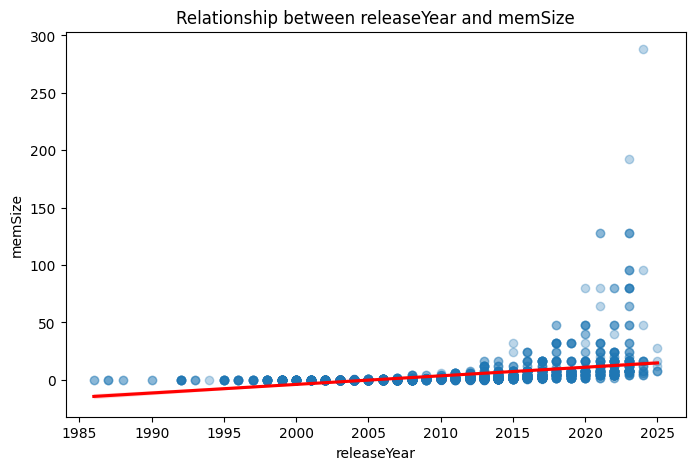

In [ ]:
# --- 6.1 Numerical-Numerical Relationships ---

# Selecting two variables to check their relationship
var1 = 'releaseYear'
var2 = 'memSize'

# Calculating correlations using the three methods
pearson_corr = df[var1].corr(df[var2], method='pearson')
spearman_corr = df[var1].corr(df[var2], method='spearman')
kendall_corr = df[var1].corr(df[var2], method='kendall')

print(f"Correlation between {var1} and {var2}:")
print(f"1. Pearson:  {pearson_corr:.4f}")
print(f"2. Spearman: {spearman_corr:.4f}")
print(f"3. Kendall:  {kendall_corr:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x=var1, y=var2, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Relationship between {var1} and {var2}')
plt.show()


* **Blue Points:** Represents an individual GPU from the dataset. Its position shows the specific relationship between its release year and its memory size.
* **Red Line:** It represents the general statistical trend, showing how memory size typically increases over the years according to the data.

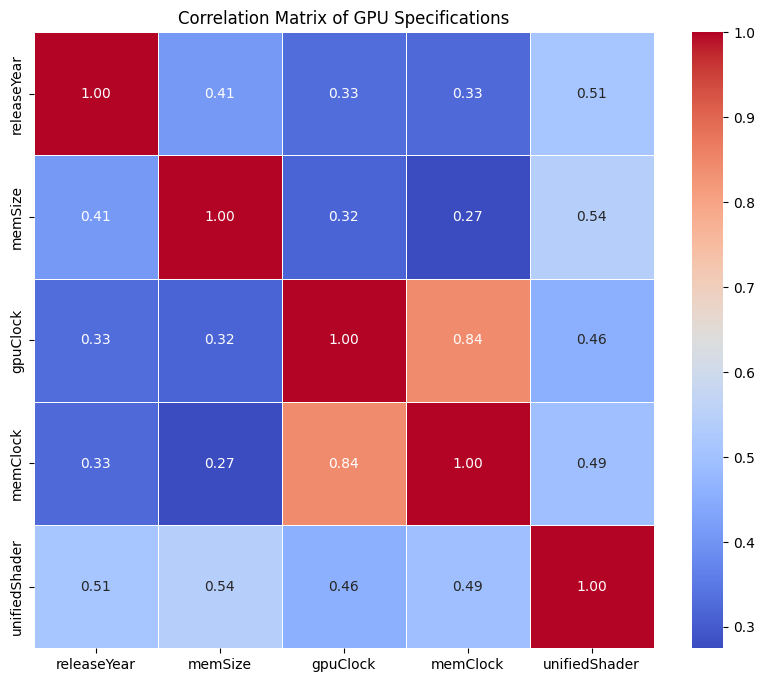

In [ ]:
numeric_cols = ['releaseYear', 'memSize', 'gpuClock', 'memClock', 'unifiedShader']
corr_matrix = df[numeric_cols].corr()

# Plotting the Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of GPU Specifications')
plt.show()


In [ ]:
# --- 6.2 Binning ---

# Binning: Dividing memory into logical tiers
# Define the boundaries (in GB)
bins = [0, 1, 4, 12, 300]
labels = ['Entry (<=1GB)', 'Mid (1-4GB)', 'High (4-12GB)', 'Extreme (>12GB)']

# Create the new categorical column
df['memTier'] = pd.cut(df['memSize'], bins=bins, labels=labels)

# Frequency Table (Raw Counts)
raw_ct = pd.crosstab(df['manufacturer'], df['memTier'])

normalized_ct = pd.crosstab(df['manufacturer'], df['memTier'], normalize='index') * 100

print("--- Raw Frequency Table (Counts) ---")
display(raw_ct)

print("\n--- Normalized Table (Percentages % per Manufacturer) ---")
display(normalized_ct.round(2))

--- Raw Frequency Table (Counts) ---


memTier,Entry (<=1GB),Mid (1-4GB),High (4-12GB),Extreme (>12GB)
manufacturer,,,,
3dfx,30,0,0,0
AMD,23,453,105,54
ATI,476,71,0,0
Intel,3,8,19,12
Matrox,34,0,0,0
NVIDIA,464,505,205,115
Sony,9,0,0,0
XGI,16,0,0,0



--- Normalized Table (Percentages % per Manufacturer) ---


memTier,Entry (<=1GB),Mid (1-4GB),High (4-12GB),Extreme (>12GB)
manufacturer,,,,
3dfx,100.00,0.00,0.00,0.00
AMD,3.62,71.34,16.54,8.50
ATI,87.02,12.98,0.00,0.00
Intel,7.14,19.05,45.24,28.57
Matrox,100.00,0.00,0.00,0.00
NVIDIA,36.00,39.18,15.90,8.92
Sony,100.00,0.00,0.00,0.00
XGI,100.00,0.00,0.00,0.00


/tmp/ipykernel_8355/3775239906.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='manufacturer', ax=axes[0, 1], palette='viridis', order=m_counts.index)
/tmp/ipykernel_8355/3775239906.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['memSize'] <= 16], x='manufacturer', y='memSize', ax=axes[1, 1], palette='Set2')
/tmp/ipykernel_8355/3775239906.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='manufacturer', y='gpuClock', ax=axes[2, 0], palette='muted')


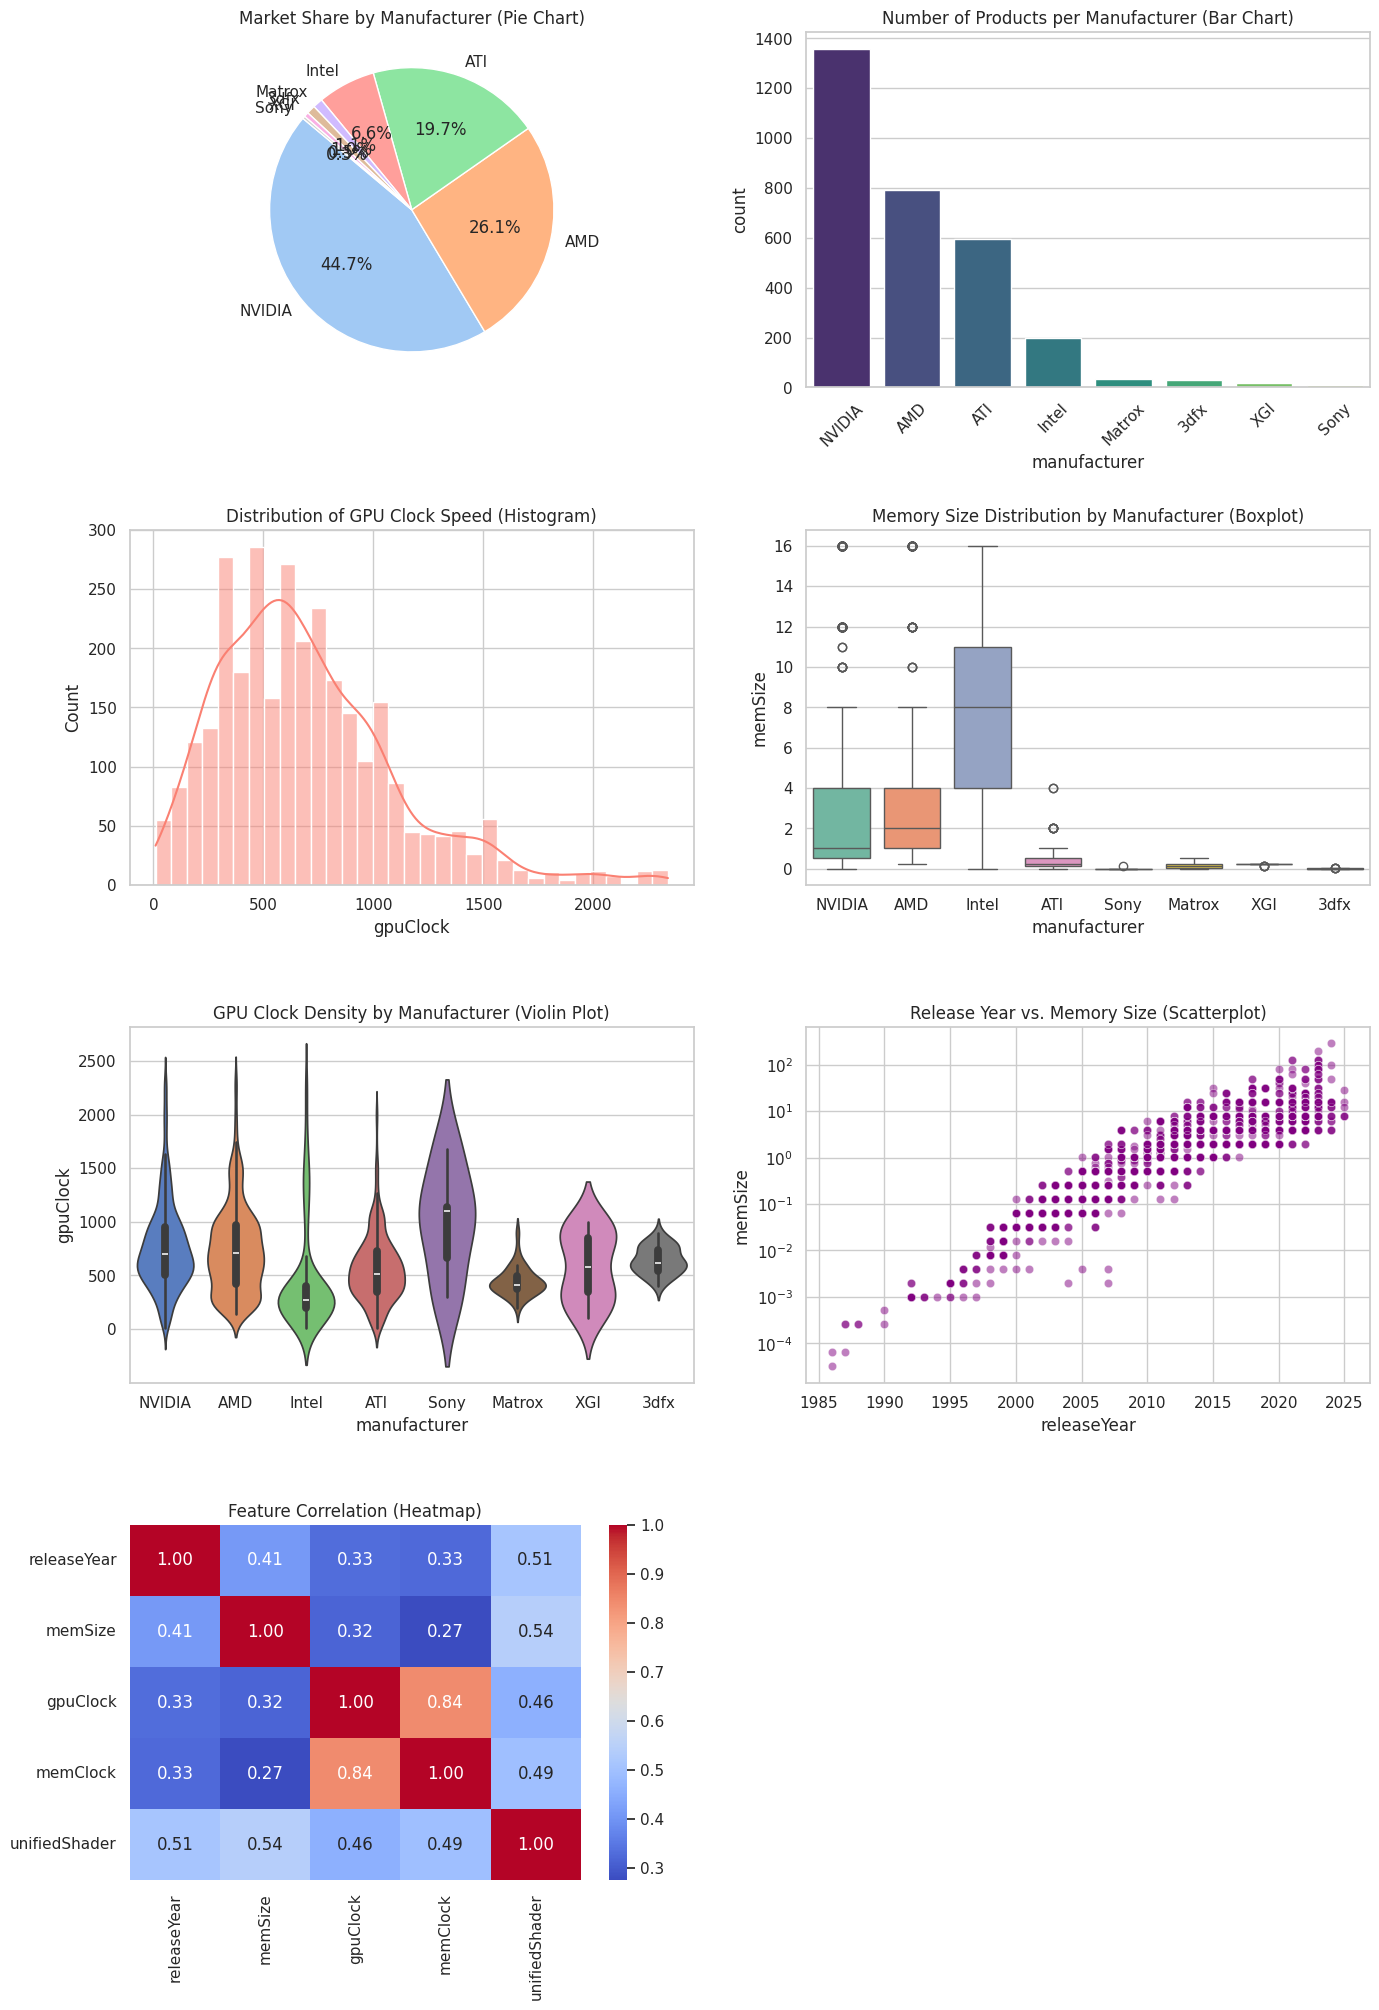

In [ ]:
# --- 6.3 Graphs ---

# Set the look of the graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 20)

# Create a layout for multiple plots (4 rows, 2 columns)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
plt.subplots_adjust(hspace=0.4)

# Pie Chart: Show the market share percentage for each brand
m_counts = df['manufacturer'].value_counts()
axes[0, 0].pie(m_counts, labels=m_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0, 0].set_title('Market Share by Manufacturer (Pie Chart)')

# Bar Chart: Count how many products each manufacturer has
sns.countplot(data=df, x='manufacturer', ax=axes[0, 1], palette='viridis', order=m_counts.index)
axes[0, 1].set_title('Number of Products per Manufacturer (Bar Chart)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Histogram: Show the distribution of GPU clock speeds
sns.histplot(df['gpuClock'].dropna(), kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of GPU Clock Speed (Histogram)')

# Boxplot: Look for extreme values (outliers) in memory size
# Note: We limit the view to 16GB so the box is visible
sns.boxplot(data=df[df['memSize'] <= 16], x='manufacturer', y='memSize', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Memory Size Distribution by Manufacturer (Boxplot)')

# Violin Plot: Show the "density" of clock speeds for each brand
sns.violinplot(data=df, x='manufacturer', y='gpuClock', ax=axes[2, 0], palette='muted')
axes[2, 0].set_title('GPU Clock Density by Manufacturer (Violin Plot)')

# Scatterplot: Show how memory size grew over the years
sns.scatterplot(data=df, x='releaseYear', y='memSize', alpha=0.5, ax=axes[2, 1], color='purple')
axes[2, 1].set_yscale('log') # סקאלה לוגריתמית בגלל ההפרשים העצומים
axes[2, 1].set_title('Release Year vs. Memory Size (Scatterplot)')

# Heatmap: Show correlation between all numbers (0 to 1)
numeric_cols = ['releaseYear', 'memSize', 'gpuClock', 'memClock', 'unifiedShader']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[3, 0])
axes[3, 0].set_title('Feature Correlation (Heatmap)')

# Hide the last empty plot area
axes[3, 1].axis('off')
plt.show()



## 7. Index analysis

In [ ]:
print(f"Is the index unique? {df.index.is_unique}")
print(f"Number of duplicate index labels: {df.index.duplicated().sum()}")

Is the index unique? True
Number of duplicate index labels: 0


## 8. The Data Story

* כשבדקנו כמה יצרנים נדרשים כדי להגיע ל-80% מהנתונים, גילינו תמונה של שוק ריכוזי מאוד. רק שלושה יצרנים מרכזיים "מכסים" את רוב המידע בטבלה. זה מראה שתחום כרטיסי המסך התפתח כשוק של מעטים, שבו חברות קטנות מתקשות לשרוד לאורך זמן מול ענקיות הטכנולוגיה.
* נמצא מתאם סטטיסטי חזק מאוד בין שנת ההשקה של כרטיסי המסך לבין נפח הזיכרון ומהירות הליבה שלהם. נתון זה מוכיח כי השוק מתאפיין בהתקדמות טכנולוגית עקבית ומהירה, שבה כל דור חדש מציג קפיצה משמעותית ביכולות החומרה לעומת קודמיו.
* נמצא פער ניכר בין הממוצע לבין החציון בנפח הזיכרון של כרטיסי המסך, דבר המעיד על התפלגות מוטה ימינה בצורה חזקה . המשמעות היא שקבוצה קטנה של כרטיסי מסך בעלי נפח זיכרון חריג וגבוה מאוד "מושכת" את הממוצע כלפי מעלה. לכן, במאגר נתונים זה, החציון הוא המדד המייצג והאמין יותר לתיאור כרטיס מסך טיפוסי.